In [104]:
# dont use the code below if word embedding is stored locally

from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [105]:
cd drive/MyDrive/MachineLearning/Lab7

[Errno 2] No such file or directory: 'drive/MyDrive/MachineLearning/Lab7'
/content/drive/MyDrive/MachineLearning/Lab7


## Preparation (3 points total)

[1 points] Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed). Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). Discuss methods of tokenization in your dataset as well as any decisions to force a specific length of sequence.  

[1 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.

[1 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Convince me that your train/test splitting method is a realistic mirroring of how an algorithm would be used in practice. 

## 


# Preparation Work

The following section completes the Preparation portion of Lab 7 by selecting a text dataset, preparing the class variable, tokenizing the text, choosing a fixed sequence length, selecting evaluation metrics, and creating a realistic train/validation/test split.


In [77]:

import os
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [78]:

os.makedirs("data", exist_ok=True)

url = "https://raw.githubusercontent.com/susanli2016/PyCon-Canada-2019-NLP-Tutorial/master/bbc-text.csv"
file_path = "data/bbc-text.csv"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

df = pd.read_csv(file_path)

print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nClass distribution:")
print(df["category"].value_counts())


        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...

Dataset shape: (2225, 2)

Columns: ['category', 'text']

Missing values:
category    0
text        0
dtype: int64

Class distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64



## Sample Text Examples

The following examples show representative BBC news articles from different categories. These examples illustrate the structure and variability of the documents used for sequence classification.


In [79]:

sample_df = df.sample(5, random_state=SEED)[["category", "text"]]

for i, row in sample_df.iterrows():
    print("=" * 80)
    print("Category:", row["category"])
    print()
    print(row["text"][:300] + "...")
    print()


Category: politics

brown and blair face new rift claims for the umpteenth time  tony blair and gordon brown are said to have declared all out war on each other.  this time the alleged rift is over who should take the credit for the government s global aid and debt initiatives  particularly in the wake of the tsunami d...

Category: business

small firms  hit by rising costs  rising fuel and materials costs are hitting confidence among the uk s small manufacturers despite a rise in output  business lobby group the cbi says.  a cbi quarterly survey found output had risen by the fastest rate in seven years but many firms were seeing the be...

Category: entertainment

spirit awards hail sideways the comedy sideways has dominated this year s independent spirit awards  winning all six of the awards for which it was nominated.  it was named best film while alexander payne won best director and best screenplay  along with writing partner jim taylor. it also won actin...

Category: tech

micr

count    2225.000000
mean      390.295281
std       241.753128
min        90.000000
25%       250.000000
50%       337.000000
75%       479.000000
max      4492.000000
Name: word_count, dtype: float64


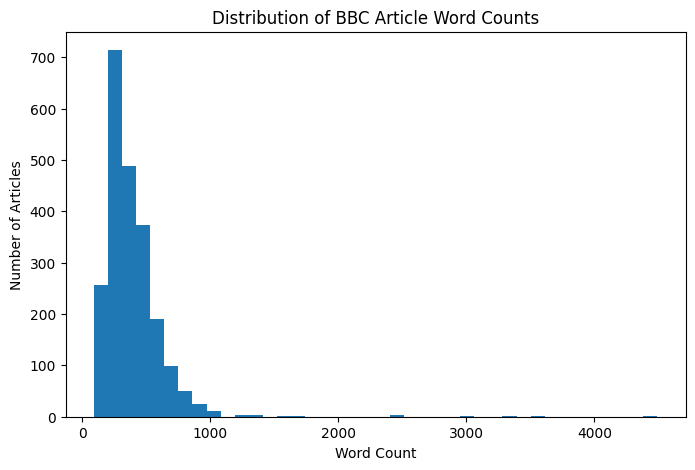

In [80]:

df["word_count"] = df["text"].str.split().str.len()

print(df["word_count"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=40)
plt.title("Distribution of BBC Article Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.show()



## Class Variable Preparation

The class variable is the `category` column, which contains five BBC news topic labels: business, entertainment, politics, sport, and tech. Since neural networks require numeric targets, the labels are encoded as integers from 0 to 4. The input variable is the article text.


In [81]:

label_encoder = LabelEncoder()
df["category_encoded"] = label_encoder.fit_transform(df["category"])

class_names = label_encoder.classes_
NUM_CLASSES = len(class_names)

print("Class mapping:")
for idx, label in enumerate(class_names):
    print(idx, "=", label)

X_text = df["text"].astype(str).values
y = df["category_encoded"].values

print("\nNumber of classes:", NUM_CLASSES)


Class mapping:
0 = business
1 = entertainment
2 = politics
3 = sport
4 = tech

Number of classes: 5



## Tokenization and Sequence Length

The text is tokenized using Keras `Tokenizer`, which converts words into integer indices based on vocabulary frequency. The vocabulary is limited to the 20,000 most common words. A maximum sequence length of 500 tokens is used because the median article length is around 337 words and the mean is around 390 words, while a small number of articles are much longer. Shorter articles are padded and longer articles are truncated.


In [82]:

top_words = 20000
max_review_length = 500

tokenizer = Tokenizer(num_words=top_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text)

sequences = tokenizer.texts_to_sequences(X_text)
X = pad_sequences(sequences, maxlen=max_review_length, padding="post", truncating="post")

word_index = tokenizer.word_index
vocab_size = min(top_words, len(word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Padded sequence shape:", X.shape)
print("Target shape:", y.shape)


Vocabulary size used: 20000
Padded sequence shape: (2225, 500)
Target shape: (2225,)



## Train, Validation, and Test Split

A stratified 70/15/15 train-validation-test split is used. Stratification is appropriate because the news categories are not perfectly balanced, and each split should preserve the original class distribution. The validation set is used for tuning, while the test set remains held out for final evaluation.


In [83]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nTraining class counts:", np.bincount(y_train))
print("Validation class counts:", np.bincount(y_val))
print("Test class counts:", np.bincount(y_test))


Training set: (1557, 500) (1557,)
Validation set: (334, 500) (334,)
Test set: (334, 500) (334,)

Training class counts: [357 270 292 357 281]
Validation class counts: [76 58 63 77 60]
Test class counts: [77 58 62 77 60]


# Modeling

In [84]:
from sklearn.utils import Bunch
bunch = Bunch(
    data = list(X_text),
    target = y,
    target_names = list(class_names),
    DESCR = "BBC news text converted to a Bunch object",
    filenames = None
)

print("len(bunch.data):", len(bunch.data))
print("bunch.target shape:", np.shape(bunch.target))
print("bunch.target_names:", bunch.target_names)

len(bunch.data): 2225
bunch.target shape: (2225,)
bunch.target_names: ['business', 'entertainment', 'politics', 'sport', 'tech']


In [85]:
%%time
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

NUM_TOP_WORDS = None # use entire vocabulary!
MAX_ART_LEN = 1000 # maximum and minimum number of words

#tokenize the text
tokenizer = Tokenizer(num_words=NUM_TOP_WORDS)
tokenizer.fit_on_texts(bunch.data)
# save as sequences with integers replacing words
sequences = tokenizer.texts_to_sequences(bunch.data)

word_index = tokenizer.word_index
NUM_TOP_WORDS = len(word_index) if NUM_TOP_WORDS==None else NUM_TOP_WORDS
top_words = min((len(word_index),NUM_TOP_WORDS))
print('Found %s unique tokens. Distilled to %d top words.' % (len(word_index),top_words))

X = pad_sequences(sequences, maxlen=MAX_ART_LEN)

y_ohe = keras.utils.to_categorical(bunch.target)
print('Shape of data tensor:', X.shape)
print('Shape of label tensor:', y_ohe.shape)
print(np.max(X))

Found 29726 unique tokens. Distilled to 29726 top words.
Shape of data tensor: (2225, 1000)
Shape of label tensor: (2225, 5)
29726
CPU times: user 1.53 s, sys: 3.37 ms, total: 1.53 s
Wall time: 1.54 s


X_train Shape: (1780, 1000) Label Shape: (1780, 5)


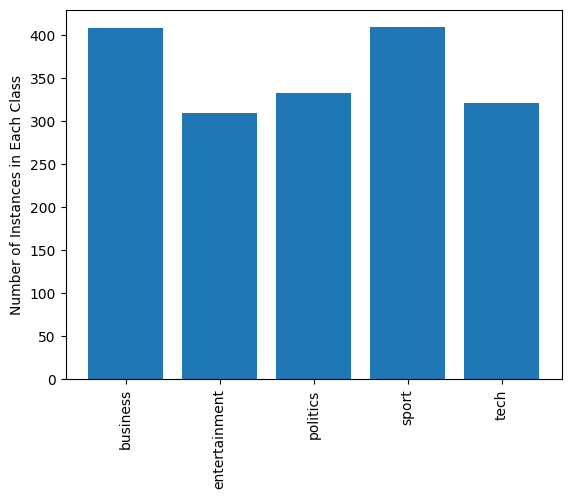

In [86]:
from sklearn.model_selection import train_test_split
from sklearn import metrics as mt
from matplotlib import pyplot as plt
%matplotlib inline

# Split it into train / test subsets
X_train, X_test, y_train_ohe, y_test_ohe = train_test_split(X, y_ohe, test_size=0.2,
                                                            stratify=bunch.target, 
                                                            random_state=42)

# print some stats of the data
print("X_train Shape:",X_train.shape, "Label Shape:", y_train_ohe.shape)
uniq_classes = np.sum(y_train_ohe,axis=0)
plt.bar(list(range(NUM_CLASSES)),uniq_classes)
plt.xticks(list(range(NUM_CLASSES)), bunch.target_names, rotation='vertical')
plt.ylabel("Number of Instances in Each Class")
plt.show()

In [106]:
%%time
EMBED_SIZE = 100
# the embed size should match the file you load glove from
embeddings_index = {}
f = open('glove.6B.100d.txt')
# save key/array pairs of the embeddings
#  the key of the dictionary is the word, the array is the embedding
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

# now fill in the matrix, using the ordering from the
#  keras word tokenizer from before
found_words = 0
embedding_matrix = np.zeros((len(word_index) + 1, EMBED_SIZE))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be ALL-ZEROS
        embedding_matrix[i] = embedding_vector
        found_words = found_words+1

print("Embedding Shape:",embedding_matrix.shape, "\n",
      "Total words found:",found_words, "\n",
      "Percentage:",100*found_words/embedding_matrix.shape[0])

Found 400000 word vectors.
Embedding Shape: (29727, 100) 
 Total words found: 27887 
 Percentage: 93.8103407676523
CPU times: user 12.9 s, sys: 506 ms, total: 13.4 s
Wall time: 16.9 s


In [107]:
from tensorflow.keras.layers import Embedding

# save this embedding now
embedding_layer = Embedding(len(word_index) + 1,
                            EMBED_SIZE,
                            weights=[embedding_matrix],# here is the embedding getting saved
                            input_length=MAX_ART_LEN,
                            trainable=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [108]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.layers import Embedding

EMBED_SIZE = 50  # same size as loaded from GLOVE
sequence_input = Input(shape=(MAX_ART_LEN,), dtype='int32')
# starting size: 1000
embedded_sequences = embedding_layer(sequence_input) # from previous embedding
x = Conv1D(128, 5, activation='relu',
           kernel_initializer='he_uniform')(embedded_sequences)

# after conv, size becomes: 1000-4=996
x = MaxPooling1D(5)(x)# after max pool, 996/5 = 199
x = Dropout(0.2)(x)
x = Conv1D(128, 5, activation='relu',
           kernel_initializer='he_uniform')(x)

# new size is 195
x = MaxPooling1D(5)(x) # after max pool, size is 195/5 = 39
x = Dropout(0.2)(x)
x = Conv1D(128, 5, activation='relu',
           kernel_initializer='he_uniform')(x)

# after convolution, size becomes 35 elements long
x = MaxPooling1D(35)(x) # this is the size to globally flatten 
# flattened vector max pools across each of the 35 elements
# so vectors is now 128 dimensions (same as num output filters)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu',
          kernel_initializer='he_uniform')(x)

preds = Dense(NUM_CLASSES, activation='softmax',
              kernel_initializer='glorot_uniform')(x)

model = Model(sequence_input, preds)

# if representing as OHE, use categorical_crossentropy
# if representing the class as an integer, use sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
              optimizer='rmsprop',
              metrics=['acc'])

print(model.summary())

histories = []
tmp = model.fit(X_train, y_train_ohe, validation_data=(X_test, y_test_ohe),
          epochs=2, batch_size=128)
histories.append(tmp)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 1000, 100)      │     2,972,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 996, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 199, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 199, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 195, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 39, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 35, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,218,081 (12.28 MB)

 Trainable params: 245,381 (958.52 KB)

 Non-trainable params: 2,972,700 (11.34 MB)

None
Epoch 1/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - acc: 0.2697 - loss: 2.4761 - val_acc: 0.4472 - val_loss: 1.3201
Epoch 2/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - acc: 0.5174 - loss: 1.2283 - val_acc: 0.6764 - val_loss: 0.8393


In [90]:
tmp = model.fit(X_train, y_train_ohe, 
                validation_data=(X_test, y_test_ohe),
                epochs=20, batch_size=128)
histories.append(tmp)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.7635 - loss: 0.6713 - val_acc: 0.9461 - val_loss: 0.3051
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - acc: 0.8270 - loss: 0.4893 - val_acc: 0.8539 - val_loss: 0.4370
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.8831 - loss: 0.3346 - val_acc: 0.7978 - val_loss: 0.6060
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - acc: 0.9039 - loss: 0.2681 - val_acc: 0.9348 - val_loss: 0.1604
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.9118 - loss: 0.2507 - val_acc: 0.9416 - val_loss: 0.1663
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - acc: 0.9404 - loss: 0.1720 - val_acc: 0.9146 - val_loss: 0.2446
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - acc: 0.9455 - loss: 0.1784 - val_acc: 0.9101 - val_loss: 0.2428
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - acc: 0.9640 - loss: 0.1185 - val_acc: 0.9236 - val_loss: 0.1877
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - acc: 0.9393 - loss: 

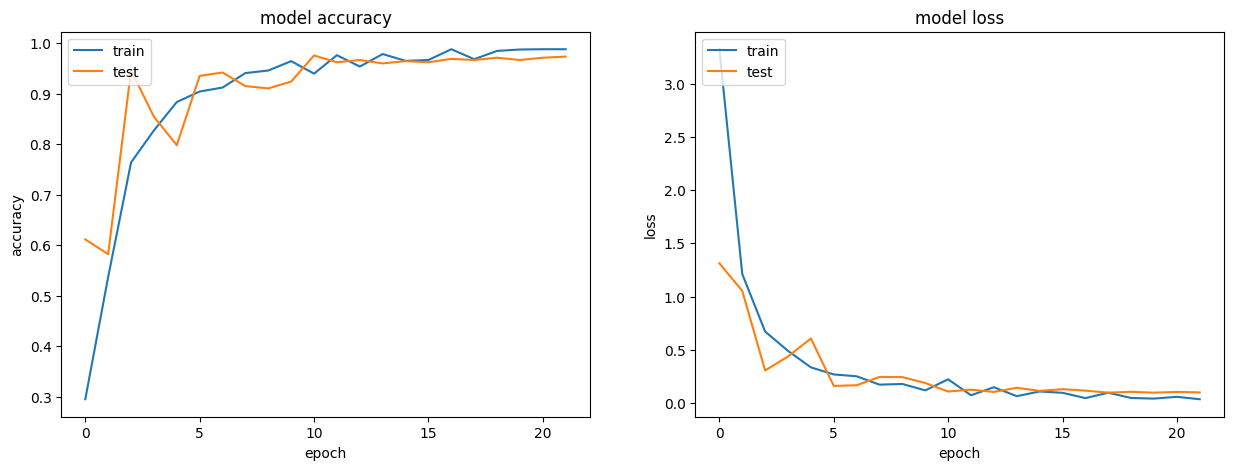

In [91]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
%matplotlib inline

# combine all the history from training together
combined = dict()
for key in ['acc','val_acc','loss','val_loss']:
    combined[key] = np.hstack([x.history[key] for x in histories])
    
# summarize history for accuracy
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(combined['acc'])
plt.plot(combined['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

# summarize history for loss
plt.subplot(122)
plt.plot(combined['loss'])
plt.plot(combined['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [109]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Layer

class GloveTokenAndPositionEmbedding(Layer):
    def __init__(self):
        super().__init__()
        # create two embeddings 
        # one for processing the tokens, pretrained (words)
        self.token_emb = Embedding(len(word_index) + 1,
                            EMBED_SIZE,
                            weights=[embedding_matrix],# here is the embedding getting saved
                            input_length=MAX_ART_LEN,
                            trainable=False)
        
        # another embedding for processing the position
        self.pos_emb = Embedding(MAX_ART_LEN, 
                                 EMBED_SIZE, 
                                 input_length=MAX_ART_LEN,
                                 trainable=True
                                )

    def call(self, x):
        # create a static position measure (input)
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        # positions now goes from 0 to 500 (for IMdB) by 1
        positions = self.pos_emb(positions)# embed these positions
        x = self.token_emb(x) # embed the tokens
        return x + positions # add embeddngs to get final embedding

In [110]:
num_heads = 4  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer

inputs = Input(shape=(X_train.shape[1],))
x = GloveTokenAndPositionEmbedding()(inputs)
x = TransformerBlock(EMBED_SIZE, num_heads, ff_dim)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
preds = Dense(NUM_CLASSES, activation='softmax',
              kernel_initializer='glorot_uniform')(x)

model_xformer20 = Model(inputs=inputs, outputs=preds)
print(model_xformer20.summary())

ValueError: Layer embedding_3 weight shape (29727, 50) is not compatible with provided weight shape (29727, 100).


## Evaluation Metric

The main evaluation metric will be macro F1-score. Macro F1 is appropriate because this is a multi-class classification task and the classes are somewhat imbalanced. Macro F1 evaluates each class equally, so the model must perform well across all five categories rather than only performing well on the largest categories. Accuracy will also be reported, but it is not the primary metric.


Modeling (6 points total)

[3 points] Investigate at least two different sequential network architectures (e.g., a CNN and a Transformer). Alternatively, you may also choose a recurrent network and Transformer network. Be sure to use an embedding layer (try to use a pre-trained embedding, if possible). Adjust one hyper-parameter of each network to potentially improve generalization performance (train a total of at least four models). Visualize the performance of training and validation sets versus the training iterations, showing that the models converged.

[1 points] Using the best parameters and architecture from the Transformer in the previous step, add a second Multi-headed self attention layer to your network. That is, the input to the second attention layer should be the output sequence of the first attention layer.  Visualize the performance of training and validation sets versus the training iterations, showing that the model converged.. 

[2 points] Use the method of train/test splitting and evaluation criteria that you argued for at the beginning of the lab. Visualize the results of all the models you trained.  Use proper statistical comparison techniques to determine which method(s) is (are) superior.  

## Exceptional Work (1 points total)

You have free reign to provide additional analyses.
One idea (required for 7000 level students to do one of these options):
Use the pre-trained ConceptNet Numberbatch embedding and compare to pre-trained GloVe. Which method is better for your specific application? 